# Irreducible mass of Black Holes

Rotating BH have a irreducible mass wich is function of the gravitational mass due to Penrose process. The relation between the two can be written as:
$$
M_{irr} = M f(\chi) = M \sqrt{\frac{1 + \sqrt{1 - \chi^2 }}{2}}
$$
We procede normalizing at 1 the true value.

In [43]:
mu = 1.0
sigma = 0.02

In [44]:
import numpy as np
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import astropy.visualization.hist as hist


In [45]:
def f_chi(x):
    return np.sqrt(0.5*(1+np.sqrt(1-x**2)))

def Mirr(M, chi):
    return M * f_chi(chi)

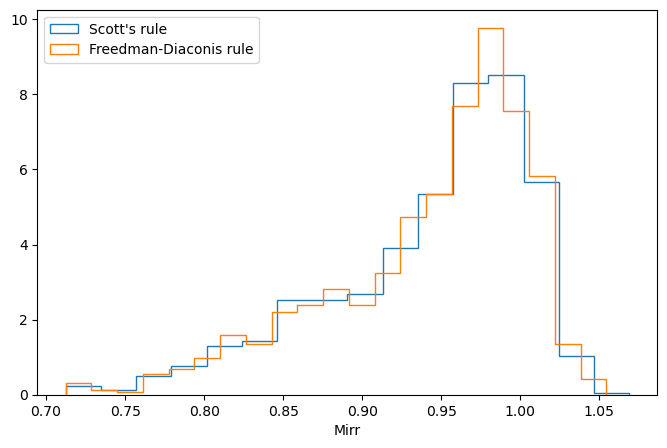

In [46]:
nsample = 1000

chi_sample = np.random.uniform(0,1, nsample)
M_sample = np.random.normal(mu, sigma, nsample)

Mirr_sample = Mirr(M_sample, chi_sample)

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.xlabel("Mirr")
plt.legend()

In [47]:
from sklearn.neighbors import KernelDensity

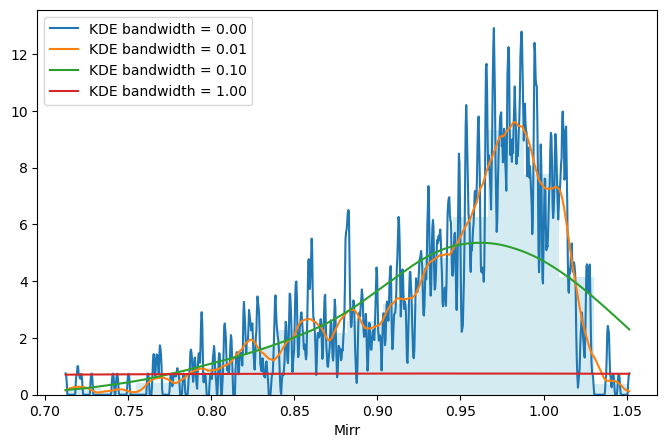

In [48]:
range_bandwidth = np.logspace(-3, 0, 4)

pdf_list = []

for bandwidth in range_bandwidth:
    kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")

    kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])

    xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

    pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))

    pdf_list.append((bandwidth, pdf_epanechnikov))

plt.figure(figsize=(8, 5))
plt.hist(Mirr_sample, bins="scott", density=True, color="lightblue", alpha=0.5)
for bandwidth, pdf in pdf_list:
    plt.plot(xgrid, pdf, "-", label="KDE bandwidth = {:.2f}".format(bandwidth))
plt.xlabel("Mirr")
plt.legend()

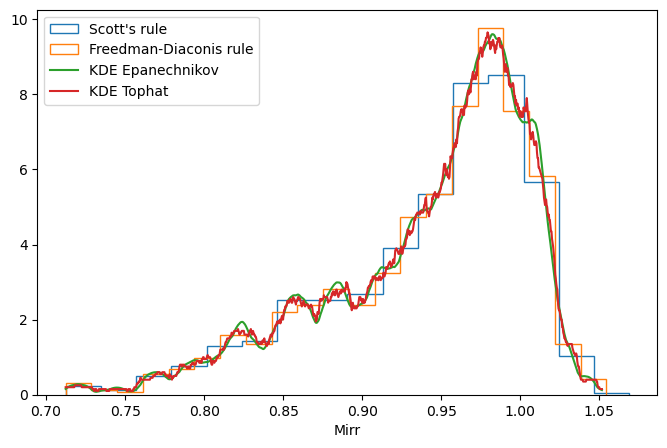

In [49]:
bandwidth = 0.01

kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")
kde_tophat = KernelDensity(bandwidth=bandwidth, kernel="tophat")

kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])
kde_tophat.fit(Mirr_sample[:, np.newaxis])

xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))
pdf_tophat = np.exp(kde_tophat.score_samples(xgrid[:, np.newaxis]))

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.plot(xgrid, pdf_epanechnikov, "-", label="KDE Epanechnikov")
plt.plot(xgrid, pdf_tophat, "-", label="KDE Tophat")
plt.xlabel("Mirr")
plt.legend()
plt.show()

Let's now compare with some analitical result.

In [50]:
def pdf_f(f_val):
    return 2 * (2 * f_val**2 - 1) / np.sqrt(1 - f_val**2)

def integrand(f, M_irr, mu, sigma):
    return np.exp(-(M_irr/f - mu)**2 / (2*sigma**2)) * (2*f**2 - 1) / (f * np.sqrt(1 - f**2))

def pdf_Mirr(M_irr, mu, sigma):
    result, _ = scipy.integrate.quad(lambda f: integrand(f, M_irr, mu, sigma), 1/np.sqrt(2), 1)
    return np.sqrt(2/np.pi) / sigma * result

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_96315/1418389081.py:2: RuntimeWarning: divide by zero encountered in divide
  return 2 * (2 * f_val**2 - 1) / np.sqrt(1 - f_val**2)


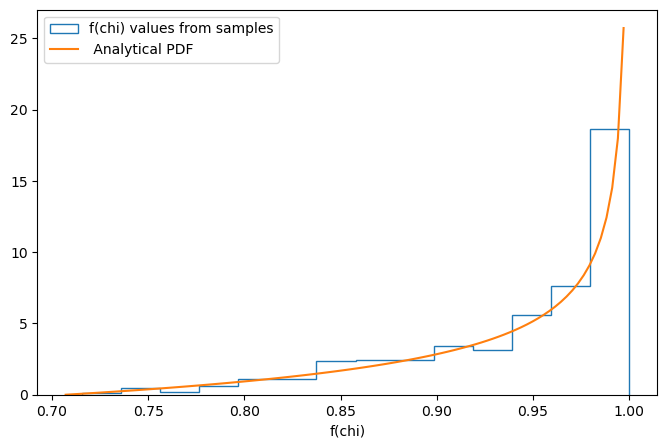

In [54]:
fgrid = np.linspace(1/np.sqrt(2), 1, 100)
pdf_f_values = pdf_f(fgrid)

plt.figure(figsize=(8, 5))
plt.hist(
    f_chi(chi_sample),
    bins="scott",
    density=True,
    histtype="step",
    label="f(chi) values from samples"
)
plt.plot(fgrid, pdf_f_values, label=" Analytical PDF")
plt.xlabel("f(chi)")
plt.legend()
plt.show()

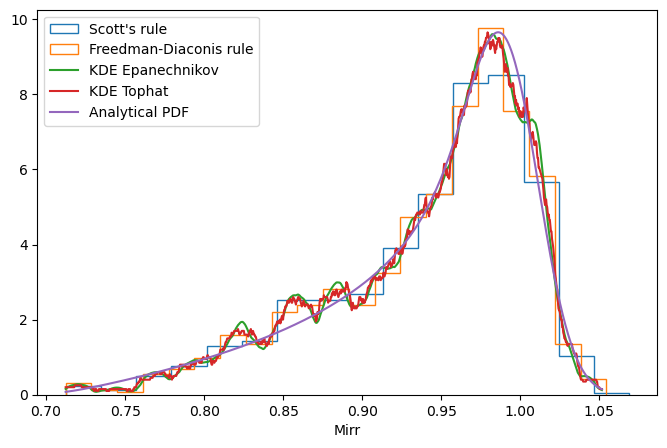

In [53]:
pdf_Mirr_values = np.array([pdf_Mirr(Mirr_val, mu, sigma) for Mirr_val in xgrid])

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.plot(xgrid, pdf_epanechnikov, "-", label="KDE Epanechnikov")
plt.plot(xgrid, pdf_tophat, "-", label="KDE Tophat")
plt.plot(xgrid, pdf_Mirr_values, "-", label="Analytical PDF")
plt.xlabel("Mirr")
plt.legend()
plt.show()

### KS test

The Kolmogorov–Smirnov (KS) test is a non-parametric test used to compare 
two probability distributions. It measures the maximum distance between 
their cumulative distribution functions (CDFs):

$$
D = \max_x |\text{CDF}_1(x) - \text{CDF}_2(x)|
$$

By construction, $ 0 \leq D \leq 1.$ A larger value of $D$ indicates a larger difference between the two 
distributions.

The p-value associated with the KS statistic measures how compatible the 
observed distance is with the two samples being drawn from the same 
underlying distribution. Therefore, a small p-value indicates that such a 
large difference would be unlikely if the two distributions were the same.

For a given significance level $\alpha$, the critical KS distance can be 
approximated as

$$
D_{\mathrm{KS}} \approx 
\sqrt{-\frac{\ln(\alpha/2)}{2n_e}}
$$

where $\alpha$ is the significance level and $n_e$ is the effective 
sample size.

In [8]:
D_Mirr_M_sample = stats.ks_2samp(Mirr_sample, M_sample)

print("KS statistic (Mirr vs M_sample):", D_Mirr_M_sample.statistic)
print("p-value (Mirr vs M_sample):", D_Mirr_M_sample.pvalue)

KS statistic (Mirr vs M_sample): 0.51
p-value (Mirr vs M_sample): 8.22523681091035e-119


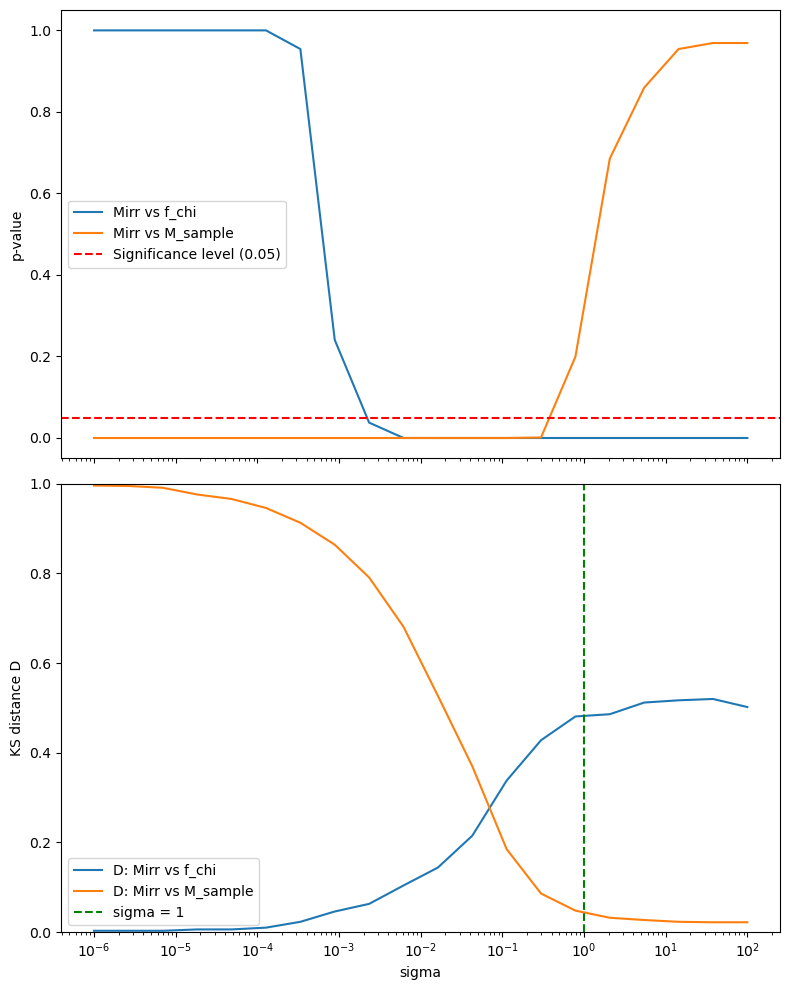

In [9]:
sigma_n = np.logspace(-6, 2, 20)

p_values_Mirr_f_chi = []
p_values_Mirr_M_sample = []
D_values_Mirr_f_chi = []
D_values_Mirr_M_sample = []

for sigma in sigma_n:
    M_sample = np.random.normal(mu, sigma, nsample)
    Mirr_sample = Mirr(M_sample, chi_sample)
    f = Mirr_sample/M_sample

    D_values_Mirr_f_chi.append(stats.ks_2samp(Mirr_sample, f).statistic)
    D_values_Mirr_M_sample.append(stats.ks_2samp(Mirr_sample, M_sample).statistic)
    p_values_Mirr_f_chi.append(stats.ks_2samp(Mirr_sample, f).pvalue)
    p_values_Mirr_M_sample.append(stats.ks_2samp(Mirr_sample, M_sample).pvalue)

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

axes[0].plot(sigma_n, p_values_Mirr_f_chi, label="Mirr vs f_chi")
axes[0].plot(sigma_n, p_values_Mirr_M_sample, label="Mirr vs M_sample")
axes[0].set_xscale("log")
axes[0].set_ylabel("p-value")
axes[0].axhline(y=0.05, color="r", linestyle="--", label="Significance level (0.05)")
axes[0].legend()

axes[1].plot(sigma_n, D_values_Mirr_f_chi, label="D: Mirr vs f_chi")
axes[1].plot(sigma_n, D_values_Mirr_M_sample, label="D: Mirr vs M_sample")
axes[1].set_xscale("log")
axes[1].set_xlabel("sigma")
axes[1].set_ylabel("KS distance D")
axes[1].set_ylim(0, 1)
axes[1].axvline(x=1, color="g", linestyle="--", label="sigma = 1")
axes[1].legend()

plt.tight_layout()
plt.show()